# Generic Trend Model

This notebook will focus on developing a simple trend following model based originally on *Tail Protection for Long Investors: Trend Convexity at Work*

# Packages

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp


import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [5]:
from tqdm import tqdm
tqdm.pandas()

In [114]:
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Collecting Data

In [7]:
root_path   = os.getcwd()
data_path   = os.path.join(root_path, "data")
fut_path    = os.path.join(data_path, "FuturesPX.parquet")
ticker_path = os.path.join(data_path, "TickerGuide.xlsx")
trend_path  = os.path.join(data_path, "TrendIndices.parquet")

In [8]:
df_fut = (pd.read_parquet(
    path = fut_path, engine = "pyarrow").
    rename(columns = {"ticker": "security"}).
    assign(ticker = lambda x: x.security.str.split("1").str[0].str.strip()))

In [9]:
good_tickers = (pd.read_excel(
    io = ticker_path, sheet_name = "fut_guide").
    rename(columns = {"Root Contract": "tmp"}).
    assign(tmp = lambda x: x.tmp.str.strip()).
    tmp.
    drop_duplicates().
    sort_values().
    to_list())

In [10]:
df_wider_px = (df_fut.query(
    "ticker == @good_tickers").
    pivot(index = "date", columns = "ticker", values = "adj_val"))

In [11]:
df_fut_rtn = (df_wider_px.pct_change(fill_method = None).reset_index().melt(
    id_vars = "date", value_name = "fut_rtn").
    dropna())

df_long_only = (df_fut_rtn.pivot(
    index = "date", columns = "ticker", values = "fut_rtn").
    apply(lambda x: x * (0.2 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    mean(axis = 1).
    to_frame(name = "Long Only"))

# Getting Benchmark Trend Data and Generating Generic Trend Signal

In [13]:
df_trend = (pd.read_parquet(
    path = trend_path, engine = "pyarrow").
    assign(
        date     = lambda x: pd.to_datetime(x.date).dt.date,
        security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change(fill_method = None)
    [["NEIXCTAT"]])

In [14]:
df_signal = (df_wider_px.diff().apply(
    lambda x: x / x.ewm(span = 10, adjust = False).std()).
    apply(lambda x: x.ewm(span = 100, adjust = False).mean()))

# Case 1: Generic Model

In [16]:
df_signal_rtn = (df_wider_px.pct_change(fill_method = None) * np.sign(df_signal.shift()))
df_vol_rtn    = (df_signal_rtn.apply(lambda x: x * (0.2 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))))

In [17]:
df_gen = (df_vol_rtn.apply(
    lambda x: np.where(np.abs(x) >= 12, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "Generic TF").
    dropna())

In [18]:
df_generic_compare = (df_trend.merge(
    right = df_gen, how = "inner", on = ["date"]).
    merge(right = df_long_only, how = "inner", on = ["date"]))

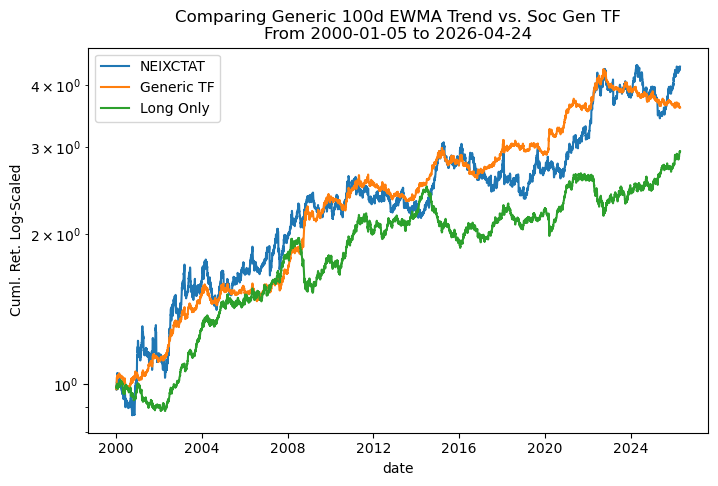

In [19]:
(df_generic_compare.
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Comparing Generic 100d EWMA Trend vs. Soc Gen TF\nFrom {} to {}".format(
            df_generic_compare.index.min(),
            df_generic_compare.index.max())))

plt.show()

In [20]:
(df_generic_compare.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "sharpe"))

,sharpe
NEIXCTAT,0.491553
Generic TF,0.748665
Long Only,0.554327


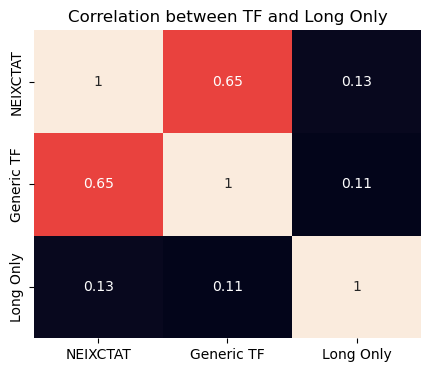

In [21]:
fig, axes = plt.subplots(figsize = (5,4))

sns.heatmap(
    ax    = axes,
    data  = df_generic_compare.corr(),
    annot = True,
    cbar  = False)

axes.set_title("Correlation between TF and Long Only")
plt.show()

# Case 2: Generic OLS Residuals

In [37]:
df_lag_signal = (df_signal.shift().reset_index().melt(
    id_vars = "date", value_name = "lag_signal").
    dropna())

In [41]:
df_rtn = (df_wider_px.pct_change().apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "vol_rtn").
    dropna())

/var/folders/_n/yt6wlv7j787g4c3skpfm8h_w0000gn/T/ipykernel_871/2511019155.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rtn = (df_wider_px.pct_change().apply(


In [43]:
def _get_ols(df: pd.DataFrame, window: int = 30) -> pd.DataFrame: 

    df_is = (sm.OLS(
        endog = df.vol_rtn,
        exog  = sm.add_constant(df.lag_signal)).
        fit().
        fittedvalues.
        to_frame(name = "is_pred"))

    oos_model = (RollingOLS(
        endog     = df.vol_rtn,
        exog      = sm.add_constant(df.lag_signal),
        expanding = True,
        min_nobs  = 30).
        fit())

    df_out = (oos_model.params.rename(
        columns = {"lag_signal": "beta"}).
        shift().
        merge(right = df, how = "inner", on = ["date"]).
        assign(os_pred = lambda x: (x.beta * x.lag_signal) + x.const).
        merge(right = df_is, how = "inner", on = ["date"]).
        drop(columns = ["const", "beta"]))

    return df_out

df_ols = (df_lag_signal.merge(
    right = df_rtn, how = "inner", on = ["date", "ticker"]).
    set_index("date").
    groupby("ticker").
    progress_apply(lambda group: _get_ols(group), include_groups = False).
    reset_index())

100%|█████████████████████████████████████████████████████████████████| 73/73 [00:38<00:00,  1.89it/s]


In [45]:
df_ols_port = (df_ols.drop(
    columns = ["lag_signal", "vol_rtn"]).
    melt(id_vars = ["date", "ticker"], var_name = "signal_name", value_name = "signal").
    dropna().
    merge(right = df_fut_rtn, how = "inner", on = ["date", "ticker"]).
    assign(signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn).
    pivot(index = "date", columns = ["signal_name", "ticker"], values = "signal_rtn").
    apply(lambda x: x * (0.2 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 10, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    dropna().
    drop(columns = ["ticker"]).
    groupby(["date", "signal_name"]).
    agg("mean").
    reset_index().
    pivot(index = "date", columns = "signal_name", values = "value").
    rename(columns = {
        "is_pred": "IS OLS",
        "os_pred": "OS OLS"}))

In [47]:
df_ols_compare = (df_ols_port.merge(
    right = df_generic_compare, how = "inner", on = ["date"]))

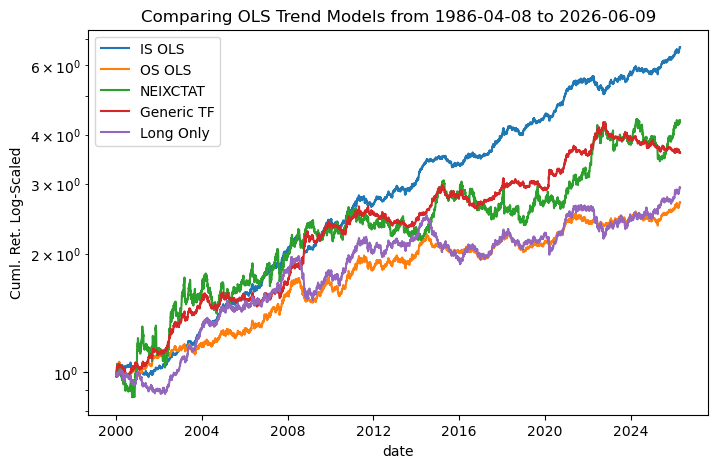

In [49]:
(df_ols_compare.apply(
    lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Comparing OLS Trend Models from {} to {}".format(
            df_ols_port.index.min(),
            df_ols_port.index.max())))

plt.show()

In [51]:
(df_ols_compare.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "Sharpe").
    T)

,IS OLS,OS OLS,NEIXCTAT,Generic TF,Long Only
Sharpe,1.339637,0.638575,0.491553,0.748665,0.554327


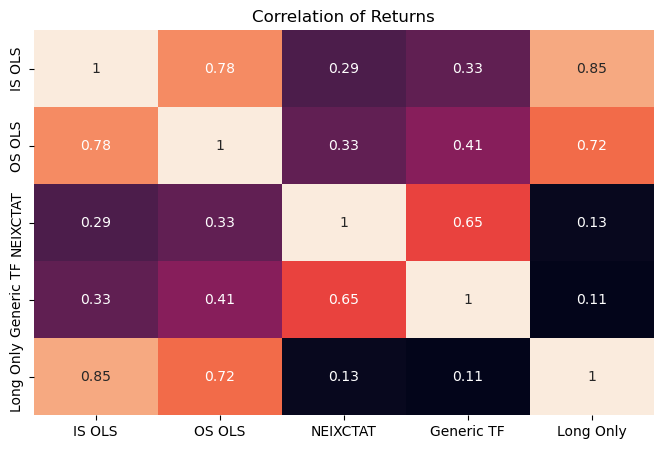

In [53]:
fig, axes = plt.subplots(figsize = (8,5))

sns.heatmap(
    ax    = axes,
    data  = df_ols_compare.corr(),
    cbar  = False,
    annot = True)

axes.set_title("Correlation of Returns")
plt.show()

In [55]:
df_combo_compare = (df_ols_compare[
    ["OS OLS", "Generic TF"]].
    mean(axis = 1).
    to_frame(name = "Combo").
    merge(right = df_ols_compare, how = "inner", on = ["date"])
    [["Combo", "NEIXCTAT", "Long Only", "Generic TF"]])

<Axes: xlabel='date'>

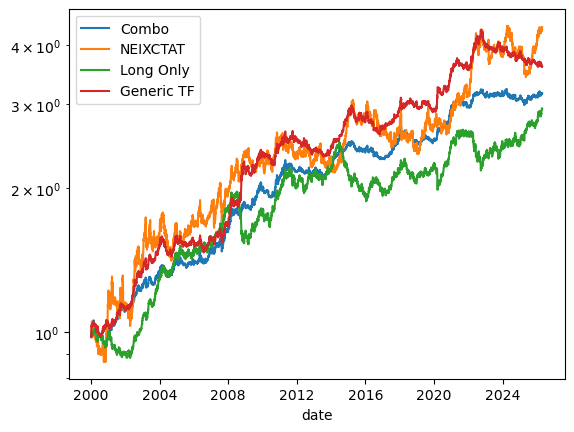

In [57]:
(df_combo_compare.apply(
    lambda x: np.cumprod(1 + x)).
    plot(logy = True))

In [59]:
(df_combo_compare.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "sharpe").
    T.
    apply(lambda x: np.round(x,3)))

,Combo,NEIXCTAT,Long Only,Generic TF
sharpe,0.828,0.492,0.554,0.749


In [61]:
def _get_performance_comparison(df: pd.DataFrame, strat1: str, strat2: str, window: int = 30) -> pd.DataFrame:

    df_strat1, df_strat2 = df[strat1], df[strat2]
    
    df_strat1_prep = (df_strat1.to_frame(
        name = "strat1").
        reset_index().
        rename(columns = {df_strat1.index.name: "date"}))

    df_strat2_prep = (df_strat2.to_frame(
        name = "strat2").
        reset_index().
        rename(columns = {df_strat1.index.name: "date"}))

    df_combined = (df_strat1_prep.merge(
        right = df_strat2_prep, how = "inner", on = ["date"]).
        set_index("date"))

    radj_spread_vals = (df_combined.apply(
        lambda x: x.rolling(window = window).mean() / x.rolling(window = window).std()).
        dropna().
        assign(spread = lambda x: x.strat1 - x.strat2).
        spread)

    spread_vals = (df_combined.assign(
        spread = lambda x: x.strat1 - x.strat2).
        spread)

    t_test, p_value         = ttest_1samp(a = spread_vals, popmean = 0)
    adj_t_test, adj_p_value = ttest_1samp(a = radj_spread_vals, popmean = 0)

    df_out = (pd.DataFrame({
        "t_stat" : [t_test, adj_t_test],
        "p_value": [p_value, adj_p_value],
        "test"   : ["raw_rtn", "radj_rtn"]}).
        assign(name = strat1 + " - " + strat2))

    return df_out

_get_performance_comparison(df_combo_compare, "Combo", "Generic TF")

,t_stat,p_value,test,name
0,-0.846158,0.397494,raw_rtn,Combo - Generic TF
1,4.619435,0.000004,radj_rtn,Combo - Generic TF


# Generic Optimized Deciles

In [428]:
def _get_decile(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 

    df_out = (df.assign(
        decile = lambda x: pd.qcut(x = x.signal, q = q, labels = [i + 1 for i in range(q)])).
        shift())

    return df_out
    
df_decile = (df_signal.reset_index().melt(
    id_vars = "date", value_name = "signal").
    dropna().
    set_index("date").
    groupby("ticker").
    apply(_get_decile, include_groups = False).
    dropna().
    reset_index())

In [430]:
df_combined = (df_rtn.merge(
    right = df_decile, how = "inner", on = ["date", "ticker"]))

In [432]:
df_decile_sharpe = (df_combined[
    ["ticker", "decile", "vol_rtn"]].
    groupby(["ticker", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"vol_rtn": "sharpe"}))

In [434]:
df_tmp_decile = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lgroup", "ugroup")))

In [436]:
df_raw_rtn = (df_wider_px.pct_change().reset_index().melt(
    id_vars = "date", value_name = "raw_rtn").
    dropna())

In [438]:
df_opt = (df_tmp_decile.drop(
    columns = ["decile"]).
    groupby(["ticker", "group"]).
    agg("prod").
    assign(signal_scaler = lambda x: np.where(x.sharpe > 0, 1, np.nan)).
    reset_index().
    drop(columns = ["sharpe"]).
    merge(right = df_tmp_decile, how = "outer", on = ["group", "ticker"]).
    merge(right = df_combined, how = "outer", on = ["ticker", "decile"]).
    merge(right = df_raw_rtn, how = "inner", on = ["date", "ticker"]).
    assign(signal_rtn = lambda x: np.sign(x.signal_scaler * x.sharpe) * x.raw_rtn))

In [440]:
df_is_decile = (df_opt.pivot(
    index = "date", columns = "ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) >= 10, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "Decile IS"))

In [442]:
df_decile_compare = (df_is_decile.merge(
    right = df_generic_compare, how = "inner", on = ["date"]))

<Axes: xlabel='date'>

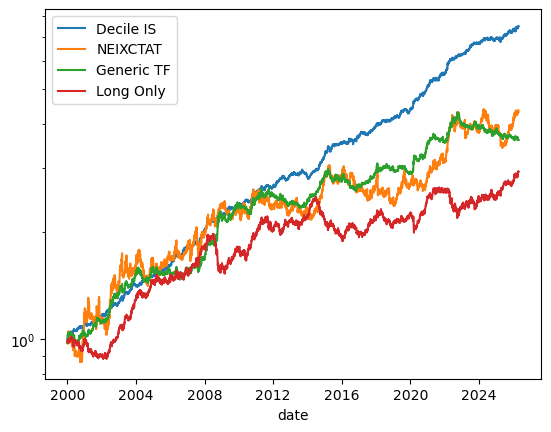

In [444]:
(df_decile_compare.apply(
    lambda x: np.cumprod(1 + x)).
    plot(logy = True))

In [446]:
(df_decile_compare.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "sharpe").
    T.
    apply(lambda x: np.round(x,3)))

,Decile IS,NEIXCTAT,Generic TF,Long Only
sharpe,2.024,0.492,0.749,0.554
